# Batch conversion of SmartSolo harvests to an SDS archive

Converts everything in one or more harvest folders (raw `seisNNN{X,Y,Z}.DLD`, node MiniSEED and `DigiSolo.LOG`) in one go, without SoloLite:

* **SDS archive** (`YEAR/NET/STA/CHA.D/NET.STA.LOC.CHA.D.YEAR.DOY`, daily Steim2 MiniSEED) – the default; or one file per window (`output.layout: files`, MiniSEED or SEG-Y);
* **harvest database** `harvest.sqlite`: which source file was converted, when, with which settings, and which day files it went into. Running again skips what is done, so new harvests can be added to the same archive; files converted with other timing settings are redone automatically;
* **StationXML + station table** for everything in the archive (AusPass response by default);
* **all settings in one YAML/JSON file**, stored with the output (`settings_used.yaml`).

The batch design (SDS writer, harvest database, parallel workers, binary GPS week/TOW timing, trailing samples, robust node MiniSEED) follows the harvest script, re-implemented on the node_toolbox readers. Authors: Tobias Stål (UTAS), Robert Pickle (ANU).

Data: the six break-test nodes in `data/break_test/` (Git LFS – `git lfs pull`).

In [1]:
import sys; sys.path.insert(0, "../../lib")
import warnings; warnings.filterwarnings("ignore")
from pathlib import Path
import shutil
import pandas as pd
import matplotlib.pyplot as plt

import smartsolo_config as sc
import smartsolo_batch as sb
import smartsolo_dld as dld

HARVEST = Path("../../data/break_test")
SETTINGS = Path("../../examples/batch_settings.yaml")

## 1. Settings

A settings file only needs what differs from the defaults. `examples/batch_settings.yaml`:

In [2]:
print(SETTINGS.read_text())

# Example settings for smartsolo_batch / notebooks/batch_convert.ipynb.
# Only values that differ from the defaults are needed; run
#   python lib/smartsolo_batch.py all_settings.yaml x --template
# for a commented list of every setting.

timing:
  tow_offset_s: 0.0          # 0 matches co-located permanent stations (R. Pickle, ANU)

data:
  invert_polarity: auto      # x -1 for IGU-16HR, not for BD3C-5
  remove_gain: false         # keep raw counts; the gain goes into the response
  encoding: STEIM2

metadata:
  network: XX
  mapping: null              # e.g. stations.csv: serial,network,station,...
  # AusPass/ANSIR published response by default. "dtcc" uses the DTCC data-sheet
  # constants (ADC 3 355 500 counts/V, 0.005 % more sensitive) - see smartsolo_node.
  response: auspass

output:
  layout: sds                # or "files" for one MiniSEED/SEG-Y file per window
  root: ../output/sds_demo

batch:
  workers: 4



Every setting, with its default and an explanation, is in `smartsolo_config.DEFAULT_CONFIG`; `write_template` writes them all to a file to edit. Typos in keys raise an error instead of being ignored.

In [3]:
sc.write_template("../../output/all_settings.yaml")
print(Path("../../output/all_settings.yaml").read_text()[:1800], "...")

# node_toolbox settings (smartsolo_config). Only values that differ from the
# defaults are needed; this template lists all of them.

timing:
  # "tow": UTC from the binary GPS week + time of week in every DLD tag (default).
  # "label": the HHMMSS/YYYYMMDD text in the tag - 1 s late before the receiver knows
  # the leap seconds, 1 s early after; jumps 2 s. Diagnostics only.
  time_source: "tow"
  # Seconds added to the GPS time of week. 0 matches co-located permanent stations
  # (R. Pickle, ANU); the earlier -1 s left the data 1 s early.
  tow_offset_s: 0.0
  # Which sample a tag refers to: "block_start" (first sample of the block before it;
  # working hypothesis) or "block_end". To be confirmed with a SoloLite export.
  tag_marks: "block_start"
  # Read samples after the last tag (file cut short at power-off).
  include_trailing: true
  # GPS - UTC. null = built-in table (18 s since 2017); set an integer if a new leap
  # second is introduced.
  leap_seconds: null

data:
  # "auto

In [4]:
cfg = sc.load_config(SETTINGS)            # relative paths: relative to the settings file
print("output root:", cfg["output"]["root"])
print("settings key:", sc.settings_key(cfg))

output root: /home/user/workspace/node_toolbox/output/sds_demo
settings key: tow+0/block_start/trail1/leapNone|pol:auto|gain:kept|STEIM2


**Responses.** `metadata.response: auspass` (default) writes the AusPass/ANSIR published IGU-16HR 3C response (257 019 225.55 counts/(m/s) for gain-removed counts), split into three stages: sensor 76.6 V/(m/s) → preamp gain → ADC 3 355 342.4 counts/V. `dtcc` uses the DTCC data-sheet constants as in the harvest script (76.6 V/(m/s) × 3 355 500 counts/V), 0.005 % more sensitive – negligible in practice, but kept as an option so results can be compared with archives made by that script. BD3C-5 nodes get their own poles and zeros.

**Gain.** By default the raw counts are kept and the preamp gain goes into the response: nothing is rounded. `data.remove_gain: true` divides by 10^(gain/20) like SoloLite and the harvest script; with integer Steim2 this rounds away resolution at gains above 0 dB (use `encoding: FLOAT32` to keep it).

## 2. Plan (dry run)

One row per deployment (first stable GPS position after each power-up, from the logs, completed with the DLD tag positions). `no data` rows are log sessions without waveform files in the folder.

In [5]:
root = Path(cfg["output"]["root"])
if root.exists():
    shutil.rmtree(root)                    # demo only: start from an empty archive
plan = sb.run_batch([HARVEST], SETTINGS, dry_run=True, verbose=False)
plan

,deployment_id,serial,start,end,n_files,status,day_files,message
0,453004362_002,453004362,2023-03-31 01:29:22+00:00,2023-03-31 02:00:10+00:00,3,planned,0,
1,453004362_003,453004362,2023-04-06 23:46:33+00:00,2023-04-07 04:06:55+00:00,0,no data,0,
2,453009194_002,453009194,2023-03-31 01:30:54+00:00,2023-03-31 01:59:18+00:00,3,planned,0,
3,453009194_003,453009194,2023-04-06 23:45:47+00:00,2023-04-07 04:08:57+00:00,0,no data,0,
4,453010029_004,453010029,2023-03-31 01:32:18+00:00,2023-03-31 01:59:06+00:00,3,planned,0,
5,453010029_005,453010029,2023-04-06 23:46:23+00:00,2023-04-07 04:06:21+00:00,0,no data,0,
6,453010047_002,453010047,2023-03-31 01:28:22+00:00,2023-03-31 01:59:10+00:00,3,planned,0,
7,453010047_003,453010047,2023-04-06 23:47:17+00:00,2023-04-07 04:10:03+00:00,0,no data,0,
8,453010077_002,453010077,2023-03-31 01:33:24+00:00,2023-03-31 02:00:12+00:00,3,planned,0,
9,453010077_003,453010077,2023-04-06 23:45:39+00:00,2023-04-07 04:01:37+00:00,0,no data,0,


## 3. Convert

Deployments run in parallel (one worker per station id, so two deployments never write the same day file at the same time), one day and one component at a time.

In [6]:
summary = sb.run_batch([HARVEST], SETTINGS, verbose=False)
summary[["deployment_id", "status", "n_files", "day_files", "message"]]

,deployment_id,status,n_files,day_files,message
0,453004362_002,converted,3,3,
1,453004362_003,no data,0,0,
2,453009194_002,converted,3,3,
3,453009194_003,no data,0,0,
4,453010029_004,converted,3,3,
5,453010029_005,no data,0,0,
6,453010047_002,converted,3,3,
7,453010047_003,no data,0,0,
8,453010077_002,converted,3,3,
9,453010077_003,no data,0,0,


In [7]:
sorted(str(p.relative_to(root)) for p in root.rglob("*") if p.is_file())[:12]

['2023/XX/04362/DPE.D/XX.04362..DPE.D.2023.090',
 '2023/XX/04362/DPN.D/XX.04362..DPN.D.2023.090',
 '2023/XX/04362/DPZ.D/XX.04362..DPZ.D.2023.090',
 '2023/XX/09194/DPE.D/XX.09194..DPE.D.2023.090',
 '2023/XX/09194/DPN.D/XX.09194..DPN.D.2023.090',
 '2023/XX/09194/DPZ.D/XX.09194..DPZ.D.2023.090',
 '2023/XX/10029/DPE.D/XX.10029..DPE.D.2023.090',
 '2023/XX/10029/DPN.D/XX.10029..DPN.D.2023.090',
 '2023/XX/10029/DPZ.D/XX.10029..DPZ.D.2023.090',
 '2023/XX/10047/DPE.D/XX.10047..DPE.D.2023.090',
 '2023/XX/10047/DPN.D/XX.10047..DPN.D.2023.090',
 '2023/XX/10047/DPZ.D/XX.10047..DPZ.D.2023.090']

## 4. The harvest database

In [8]:
db = sb.HarvestDB(root / "harvest.sqlite")
display(db.table("runs")[["run_id", "started", "finished", "settings_key", "n_jobs", "n_errors"]])
display(db.table("files")[["path", "serial", "component", "time_cal", "starttime", "endtime"]].head(6))
display(db.table("outputs")[["sds_file", "npts", "deployment_id"]].head(6))
db.close()

,run_id,started,finished,settings_key,n_jobs,n_errors
0,1,2026-10-07T01:20:16+00:00,2026-10-07T01:20:18+00:00,tow+0/block_start/trail1/leapNone|pol:auto|gai...,6,0


,path,serial,component,time_cal,starttime,endtime
0,/home/user/workspace/node_toolbox/data/break_t...,453004362,X,tow+0/block_start,2023-03-31 01:29:22+00:00,2023-03-31 02:00:09.998000+00:00
1,/home/user/workspace/node_toolbox/data/break_t...,453004362,Y,tow+0/block_start,2023-03-31 01:29:22+00:00,2023-03-31 02:00:09.998000+00:00
2,/home/user/workspace/node_toolbox/data/break_t...,453004362,Z,tow+0/block_start,2023-03-31 01:29:22+00:00,2023-03-31 02:00:09.998000+00:00
3,/home/user/workspace/node_toolbox/data/break_t...,453009194,X,tow+0/block_start,2023-03-31 01:30:54+00:00,2023-03-31 01:59:17.998000+00:00
4,/home/user/workspace/node_toolbox/data/break_t...,453009194,Y,tow+0/block_start,2023-03-31 01:30:54+00:00,2023-03-31 01:59:17.998000+00:00
5,/home/user/workspace/node_toolbox/data/break_t...,453009194,Z,tow+0/block_start,2023-03-31 01:30:54+00:00,2023-03-31 01:59:17.998000+00:00


,sds_file,npts,deployment_id
0,/home/user/workspace/node_toolbox/output/sds_d...,924000,453004362_002
1,/home/user/workspace/node_toolbox/output/sds_d...,924000,453004362_002
2,/home/user/workspace/node_toolbox/output/sds_d...,924000,453004362_002
3,/home/user/workspace/node_toolbox/output/sds_d...,852000,453009194_002
4,/home/user/workspace/node_toolbox/output/sds_d...,852000,453009194_002
5,/home/user/workspace/node_toolbox/output/sds_d...,852000,453009194_002


## 5. Running again

Nothing has changed, so everything is skipped. A new harvest folder given in `inputs` would be added to the archive.

In [9]:
sb.run_batch([HARVEST], SETTINGS, verbose=False)[["deployment_id", "status"]].head(4)

,deployment_id,status
0,453004362_002,skipped
1,453004362_003,no data
2,453009194_002,skipped
3,453009194_003,no data


Changing a timing setting (here back to the old −1 s TOW offset, for illustration only) marks the files as converted with other timing: they are redone and their samples in the day files replaced, not duplicated.

In [10]:
from obspy import read
day = next(root.rglob("XX.10029..DPZ.D.2023.090"))
print("before:", read(str(day))[0])
sb.run_batch([HARVEST], SETTINGS, verbose=False, timing__tow_offset_s=-1.0)
print("old -1 s:", read(str(day))[0])
s = sb.run_batch([HARVEST], SETTINGS, verbose=False)        # back to the correct 0 s
print("again 0 s:", read(str(day))[0])
s[["deployment_id", "status"]].head(2)

before: XX.10029..DPZ | 2023-03-31T01:32:18.000000Z - 2023-03-31T01:59:05.998000Z | 500.0 Hz, 804000 samples


old -1 s: XX.10029..DPZ | 2023-03-31T01:32:17.000000Z - 2023-03-31T01:59:04.998000Z | 500.0 Hz, 804000 samples


again 0 s: XX.10029..DPZ | 2023-03-31T01:32:18.000000Z - 2023-03-31T01:59:05.998000Z | 500.0 Hz, 804000 samples


,deployment_id,status
0,453004362_002,redone
1,453004362_003,no data


## 6. Using the archive

Any SDS client works, e.g. ObsPy's, together with the StationXML.

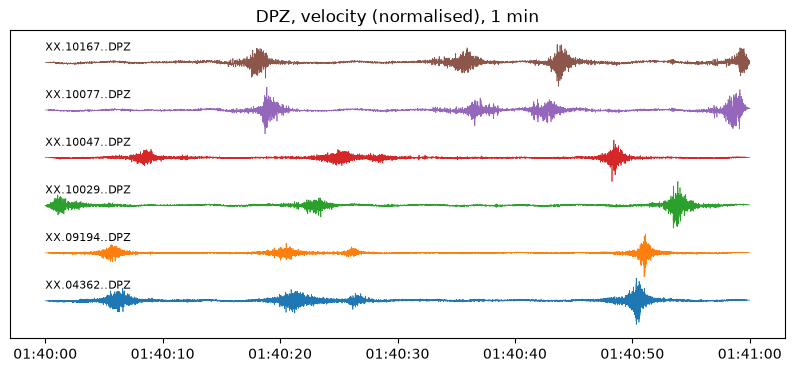

Channel Response
	From M/S () to COUNTS ()
	Overall Sensitivity: 2.55456e+08 defined at 15.000 Hz
	3 stages:
		Stage 1: PolesZerosResponseStage from M/S to V, gain: 76.134
		Stage 2: ResponseStage from V to V, gain: 1
		Stage 3: CoefficientsTypeResponseStage from V to COUNTS, gain: 3.35534e+06


In [11]:
from obspy import UTCDateTime, read_inventory
from obspy.clients.filesystem.sds import Client
client = Client(str(root))
inv = read_inventory(str(root / "stations.xml"))
t0 = UTCDateTime("2023-03-31T01:40:00")
st = client.get_waveforms("XX", "*", "", "DPZ", t0, t0 + 60)
st.attach_response(inv)
st.remove_response(output="VEL")
fig, ax = plt.subplots(figsize=(10, 4))
for k, tr in enumerate(st.sort()):
    ax.plot(tr.times("matplotlib"), tr.data / abs(tr.data).max() + 2 * k, lw=0.5)
    ax.text(tr.times("matplotlib")[0], 2 * k + 0.5, tr.id, fontsize=8)
ax.xaxis_date(); ax.set_yticks([]); ax.set_title("DPZ, velocity (normalised), 1 min")
plt.show()
print(inv.select(station="10029", channel="DPZ")[0][0][0].response)

In [12]:
pd.read_csv(root / "stations.csv").head()

,deployment_id,serial,session,log_file,start,end,n_records,n_fixes,latitude,longitude,...,geophone_test_noisy,test_resonate_freq_hz_mean,test_damping_mean,test_sensitivity_mean,test_resistance_ohm_mean,duration,source,dld_files,sel_start,sel_end
0,453004362_002,453004362,2,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:29:22+00:00,2023-03-31 02:00:09.998000+00:00,15,3,-42.902513,147.329293,...,False,5.044033,0.703033,77.255233,1741.900000,0 days 00:30:47.998000,log,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:29:22+00:00,2023-03-31 02:00:10+00:00
1,453009194_002,453009194,2,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:30:54+00:00,2023-03-31 01:59:17.998000+00:00,12,3,-42.902456,147.329333,...,False,5.053267,0.699733,76.297533,1737.966667,0 days 00:28:23.998000,log,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:30:54+00:00,2023-03-31 01:59:18+00:00
2,453010029_004,453010029,4,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:32:18+00:00,2023-03-31 01:59:05.998000+00:00,13,3,-42.902213,147.329652,...,False,4.992367,0.705633,76.341267,1739.666667,0 days 00:26:47.998000,log,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:32:18+00:00,2023-03-31 01:59:06+00:00
3,453010047_002,453010047,2,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:28:22+00:00,2023-03-31 01:59:09.998000+00:00,15,3,-42.902653,147.329122,...,True,4.938100,0.631133,72.661800,1736.900000,0 days 00:30:47.998000,log,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:28:22+00:00,2023-03-31 01:59:10+00:00
4,453010077_002,453010077,2,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:33:24+00:00,2023-03-31 02:00:11.998000+00:00,11,3,-42.901756,147.330097,...,False,26013.818267,0.463767,2461.405033,1749.133333,0 days 00:26:47.998000,log,/home/user/workspace/node_toolbox/data/break_t...,2023-03-31 01:33:24+00:00,2023-03-31 02:00:12+00:00


## 7. Timing diagnostics

The UTC times come from the binary GPS week and time of week in each DLD tag (`tick = week << 32 | tow_ms`), so they are continuous across the weekly TOW rollover and do not depend on the HHMMSS text labels (1 s late/early around the leap-second update). `sync_age_s` is the time since the last GPS synchronisation; long values mean the clock was free-running (`max_sync_age_s` per segment in `scan_dld`).

{'serial': '453010029', 'component': 'Z', 'starttime': Timestamp('2023-03-31 01:32:18+0000', tz='UTC'), 'endtime': Timestamp('2023-03-31 01:59:05.998000+0000', tz='UTC'), 'sampling_rate': 500.0, 'npts': 804000, 'project_name': 'UTASTesting', 'firmware': 'V1.0.5.6kp', 'leap_seconds': 0, 'max_sync_age_s': 496.0, 'time_cal': 'tow+0/block_start'}


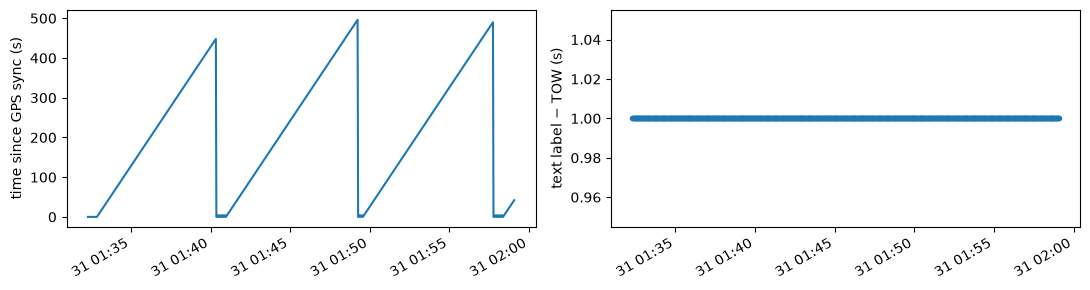

In [13]:
f = next(HARVEST.glob("453010029/*/seis000Z.DLD"))
tags = dld.read_dld_tags(f)
print(dld.scan_dld(f)[0])
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
ax[0].plot(tags["time"], tags["sync_age_s"]); ax[0].set_ylabel("time since GPS sync (s)")
ax[1].plot(tags["time"], tags["label_minus_tow_s"], ".") ; ax[1].set_ylabel("text label − TOW (s)")
fig.autofmt_xdate(); plt.tight_layout(); plt.show()

## 8. Window files instead of SDS

`output.layout: files` writes one file per `output.chunk` (e.g. `1h`, `1D`) and deployment, MiniSEED or SEG-Y – for SEG-Y workflows or when only a short window is needed (`selection.start/end`, `point`/`radius_km`, `polygon`).

In [14]:
files_root = Path("../../output/batch_files_demo")
if files_root.exists():
    shutil.rmtree(files_root)
s = sb.run_batch([HARVEST], SETTINGS, verbose=False,
                 output__layout="files", output__root=str(files_root), output__format="SEGY",
                 output__chunk="10min", selection__start="2023-03-31T01:40:00",
                 selection__end="2023-03-31T02:00:00")
sorted(str(p.relative_to(files_root)) for p in files_root.rglob("*.sgy"))[:6]

['XX/04362/XX.04362..DPE__20230331T014000Z__20230331T015000Z.sgy',
 'XX/04362/XX.04362..DPE__20230331T015000Z__20230331T020000Z.sgy',
 'XX/04362/XX.04362..DPN__20230331T014000Z__20230331T015000Z.sgy',
 'XX/04362/XX.04362..DPN__20230331T015000Z__20230331T020000Z.sgy',
 'XX/04362/XX.04362..DPZ__20230331T014000Z__20230331T015000Z.sgy',
 'XX/04362/XX.04362..DPZ__20230331T015000Z__20230331T020000Z.sgy']

## 9. Command line

The same from a terminal (e.g. on the harvest PC):

```bash
python lib/smartsolo_batch.py my_settings.yaml x --template      # write a template
python lib/smartsolo_batch.py my_settings.yaml /media/harvest_01 /media/harvest_02 --dry-run
python lib/smartsolo_batch.py my_settings.yaml /media/harvest_01 /media/harvest_02
```

Source files are only ever read; the converter never deletes anything outside the day files it updates.